In [1]:
# Cell 1: Imports
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import random
from sklearn.utils import resample

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Num GPUs Available: {len(tf.config.experimental.list_physical_devices('GPU'))}")

TensorFlow Version: 2.16.2
Num GPUs Available: 0


In [4]:
# Cell 2: Configuration (No PCA)
PROCESSED_DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'notebooks/steinmetz_data_downloads'))
print(f"Data will be loaded from: {PROCESSED_DATA_DIR}")

TARGET_BRAIN_REGION_X = 'VISp'
TARGET_BRAIN_REGION_Y = 'MOs'

X_TIME_WINDOW_START_POST_EVENT_MS = 0
X_TIME_WINDOW_END_POST_EVENT_MS = 500

Y_TIME_WINDOW_BEFORE_RESPONSE_MS = 100
Y_TIME_WINDOW_AFTER_RESPONSE_MS = 100

N_EPOCHS = 100
BATCH_SIZE = 64
LSTM_UNITS_1 = 128
LSTM_UNITS_2 = 64
DENSE_UNITS_REG = 64
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.001
N_SPLITS_CV = 5
EARLY_STOPPING_PATIENCE = 20

APPLY_PCA_X = False
N_PCA_COMPONENTS_X = None
APPLY_PCA_Y = False
N_PCA_COMPONENTS_Y = None

APPLY_UPSAMPLING = True

Data will be loaded from: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads


In [5]:
# Cell 3: Data Loading (Corrected for steinmetz_partX.npz and steinmetz_lfp.npz)
def load_steinmetz_npz_data(data_dir):
    # --- DEBUG BLOCK START ---
    print(f"[DEBUG] data_dir received by function: {data_dir}")
    try:
        print(f"[DEBUG] Contents of data_dir ({data_dir}) according to os.listdir(): {os.listdir(data_dir)}")
    except Exception as e:
        print(f"[DEBUG] Error listing data_dir: {e}")
    debug_path_part0 = os.path.join(data_dir, 'steinmetz_part0.npz')
    print(f"[DEBUG] Checking path: {debug_path_part0}")
    print(f"[DEBUG] os.path.exists(debug_path_part0): {os.path.exists(debug_path_part0)}")
    print(f"[DEBUG] os.path.isfile(debug_path_part0): {os.path.isfile(debug_path_part0)}")
    # --- DEBUG BLOCK END ---
    alldat_list = []
    main_npz_files = [os.path.join(data_dir, f'steinmetz_part{j}.npz') for j in range(3)]

    print(f"Loading main data (steinmetz_part*.npz files) from {data_dir}:")
    for f_path in main_npz_files:
        f_name = os.path.basename(f_path)
        if not os.path.isfile(f_path):
            print(f"Error: Main data file {f_name} not found in {data_dir}.")
            raise FileNotFoundError(f"Required main data file {f_name} is missing from {data_dir}. Cannot proceed.")
        print(f"  - Loading {f_name}...")
        try:
            data_part = np.load(f_path, allow_pickle=True)
            if 'dat' in data_part and isinstance(data_part['dat'], (list, np.ndarray)):
                if len(data_part['dat']) > 0 and isinstance(data_part['dat'][0], dict):
                    alldat_list.extend(data_part['dat'])
                else:
                     print(f"Warning: 'dat' in {f_name} is not a list/array of dictionaries as expected.")
            else:
                print(f"Warning: File {f_name} does not contain a 'dat' key, or 'dat' is not a list/array.")
        except Exception as e:
            print(f"Critical error loading {f_name}: {e}")
            raise

    if not alldat_list:
        raise ValueError(f"No main session data could be loaded from {main_npz_files}. Check file contents and paths.")
    print(f"Successfully loaded main data for {len(alldat_list)} sessions.")

    lfp_file_path = os.path.join(data_dir, 'steinmetz_lfp.npz')
    if not os.path.isfile(lfp_file_path):
        raise FileNotFoundError(f"'steinmetz_lfp.npz' not found in {data_dir}. Please ensure it was downloaded correctly.")

    print(f"\nLoading LFP data from: {os.path.basename(lfp_file_path)}...")
    dat_LFP_list = []
    try:
        dat_LFP_all_sessions_raw = np.load(lfp_file_path, allow_pickle=True)['dat']
        if isinstance(dat_LFP_all_sessions_raw, np.ndarray) and dat_LFP_all_sessions_raw.ndim == 1 and \
           len(dat_LFP_all_sessions_raw) > 0 and isinstance(dat_LFP_all_sessions_raw[0], dict):
            dat_LFP_list = list(dat_LFP_all_sessions_raw)
        elif isinstance(dat_LFP_all_sessions_raw, list) and len(dat_LFP_all_sessions_raw) > 0 and \
             isinstance(dat_LFP_all_sessions_raw[0], dict):
            dat_LFP_list = dat_LFP_all_sessions_raw
        else:
            raise ValueError("'dat' key in LFP file is not in the expected format (list/array of dictionaries).")
        print(f"Successfully loaded LFP data for {len(dat_LFP_list)} sessions.")
    except Exception as e:
        raise ValueError(f"Error loading 'steinmetz_lfp.npz': {e}")

    if len(alldat_list) != len(dat_LFP_list):
        print(f"Warning: Number of main sessions ({len(alldat_list)}) does not match LFP sessions ({len(dat_LFP_list)}).")
        min_sessions = min(len(alldat_list), len(dat_LFP_list))
        if min_sessions == 0:
            raise ValueError("Zero sessions available after aligning main data and LFP data counts.")
        alldat_list = alldat_list[:min_sessions]
        dat_LFP_list = dat_LFP_list[:min_sessions]
        print(f"Adjusted to {min_sessions} sessions for both main data and LFP data.")
        
    return alldat_list, dat_LFP_list

alldat, dat_LFP = load_steinmetz_npz_data(PROCESSED_DATA_DIR)

[DEBUG] data_dir received by function: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads
[DEBUG] Contents of data_dir (/Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads) according to os.listdir(): ['steinmetz_lfp.npz', 'steinmetz_part0.npz', 'steinmetz_part1.npz', 'steinmetz_part2.npz']
[DEBUG] Checking path: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads/steinmetz_part0.npz
[DEBUG] os.path.exists(debug_path_part0): True
[DEBUG] os.path.isfile(debug_path_part0): True
Loading main data (steinmetz_part*.npz files) from /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads:
  - Loading steinmetz_part0.npz...
  - Loading steinmetz_part1.npz...
  - Loading steinmetz_part2.npz...
Successfully loaded main data for 39 sessions.

Loading LFP data from: steinmetz_lfp.npz...
Successfully loaded LFP data f

In [6]:
# Cell 4: Helper Function - Mouse Details
mouse_age_data = {
    'Cori': 11, 'Forssmann': 26, 'Hench': 31, 'Lederberg': 15, 
    'Moniz': 30, 'Muller': 17, 'Radnitz': 20, 'Richards': 26, 
    'Tatum': 15, 'Theiler': 46 
}
YOUNGER_THRESHOLD_WEEKS = 20 

def get_mouse_details_by_session(session_idx, session_data_main):
    mouse_name = session_data_main.get('mouse_name', f"MouseUnknown_S{session_idx}")
    mouse_age_weeks = mouse_age_data.get(mouse_name)
    age_category = 'Unknown'
    if mouse_age_weeks is not None:
        age_category = 'Younger' if mouse_age_weeks <= YOUNGER_THRESHOLD_WEEKS else 'Older'
    return mouse_name, mouse_age_weeks, age_category

In [8]:
# Cell 5: Data Preprocessing for MOs LFP Prediction (No PCA, multi-channel X)
all_X_data = [] 
all_Y_data = [] 
all_session_ids = []
all_mouse_names = []
all_age_categories = []
all_trial_indices_original = [] 

print(f"Processing {len(alldat)} sessions...")

for session_idx in range(len(alldat)):
    session_data_main = alldat[session_idx]
    session_data_lfp = dat_LFP[session_idx]
    event_source_for_X = "stim_onset" 

    mouse_name, mouse_age, age_category = get_mouse_details_by_session(session_idx, session_data_main)
    if age_category == 'Unknown':
        continue
        
    print(f'\n--- Processing Session {session_idx} (Mouse: {mouse_name}, Age: {mouse_age}w, Category: {age_category}) ---')
    
    required_lfp_keys = ['lfp', 'brain_area_lfp']
    if any(key not in session_data_lfp for key in required_lfp_keys):
        print(f'  Warning: Session {session_idx} missing LFP keys. Skipping.')
        continue
        
    required_main_keys = ['stim_onset', 'response_time', 'bin_size']
    if any(key not in session_data_main for key in required_main_keys):
        print(f'  Warning: Session {session_idx} missing main data keys. Skipping.')
        continue

    lfp_all_channels = session_data_lfp['lfp'] 
    lfp_brain_areas = np.array(session_data_lfp['brain_area_lfp'])
    dt_lfp_s = session_data_main['bin_size'] 
    if not isinstance(dt_lfp_s, (int, float)) or dt_lfp_s <= 0:
        print(f"  Warning: Invalid bin_size for session {session_idx}. Skipping.")
        continue
    n_trials_lfp = lfp_all_channels.shape[1]

    response_times_orig = session_data_main['response_time']
    response_times = np.asarray(response_times_orig).squeeze()
    if response_times.ndim == 0: response_times = np.array([response_times.item()])
    n_trials_resp = len(response_times)

    event_times_for_X = None
    stim_onset_times_orig = session_data_main['stim_onset']
    stim_onset_times = np.asarray(stim_onset_times_orig).squeeze()
    if stim_onset_times.ndim == 0: stim_onset_times = np.array([stim_onset_times.item()])
    n_trials_stim = len(stim_onset_times)

    if n_trials_stim > 1 and (n_trials_stim == n_trials_lfp or n_trials_stim == n_trials_resp):
        event_times_for_X = stim_onset_times
        event_source_for_X = "stim_onset"
    else:
        gocue_times_orig = session_data_main.get('gocue')
        if gocue_times_orig is not None:
            gocue_times = np.asarray(gocue_times_orig).squeeze()
            if gocue_times.ndim == 0: gocue_times = np.array([gocue_times.item()])
            n_trials_gocue = len(gocue_times)
            if n_trials_gocue > 1 and (n_trials_gocue == n_trials_lfp or n_trials_gocue == n_trials_resp):
                event_times_for_X = gocue_times
                event_source_for_X = "gocue"
            else:
                continue
        else:
            continue
            
    if event_times_for_X is None:
        continue

    n_trials_event_X = len(event_times_for_X)
    n_trials_session = min(n_trials_lfp, n_trials_event_X, n_trials_resp)

    if n_trials_session == 0:
        continue
        
    if n_trials_lfp != n_trials_session: lfp_all_channels = lfp_all_channels[:, :n_trials_session, :]
    if n_trials_event_X != n_trials_session: event_times_for_X = event_times_for_X[:n_trials_session]
    if n_trials_resp != n_trials_session: response_times = response_times[:n_trials_session]
    
    visp_channel_indices = np.where(lfp_brain_areas == TARGET_BRAIN_REGION_X)[0]
    if len(visp_channel_indices) == 0:
        continue
    lfp_visp_all_trials = lfp_all_channels[visp_channel_indices, :, :]
    
    x_start_s_rel_event = X_TIME_WINDOW_START_POST_EVENT_MS / 1000.0
    x_end_s_rel_event = X_TIME_WINDOW_END_POST_EVENT_MS / 1000.0
    
    mos_channel_indices = np.where(np.isin(lfp_brain_areas, [TARGET_BRAIN_REGION_Y, 'MOs', 'MOp']))[0]
    if len(mos_channel_indices) == 0:
        continue
    lfp_mos_all_trials = lfp_all_channels[mos_channel_indices, :, :] 
    
    y_window_before_s = Y_TIME_WINDOW_BEFORE_RESPONSE_MS / 1000.0
    y_window_after_s = Y_TIME_WINDOW_AFTER_RESPONSE_MS / 1000.0
    
    session_X_data_list = []
    session_Y_data_list = []
    session_trial_ids_list = []
    
    for trial_idx in range(n_trials_session): 
        event_t_x = event_times_for_X[trial_idx]
        response_t = response_times[trial_idx]
        if np.isnan(event_t_x) or np.isnan(response_t): continue
        x_window_start_abs_s = event_t_x + x_start_s_rel_event
        x_window_end_abs_s = event_t_x + x_end_s_rel_event
        x_start_lfp_idx = int(np.round(x_window_start_abs_s / dt_lfp_s))
        x_end_lfp_idx = int(np.round(x_window_end_abs_s / dt_lfp_s))
        if not (0 <= x_start_lfp_idx < x_end_lfp_idx <= lfp_visp_all_trials.shape[2]): continue
        x_trial_lfp = lfp_visp_all_trials[:, trial_idx, x_start_lfp_idx:x_end_lfp_idx]
        if x_trial_lfp.shape[1] == 0: continue
        y_window_start_abs_s = response_t - y_window_before_s
        y_window_end_abs_s = response_t + y_window_after_s
        y_start_lfp_idx = int(np.round(y_window_start_abs_s / dt_lfp_s))
        y_end_lfp_idx = int(np.round(y_window_end_abs_s / dt_lfp_s))
        if not (0 <= y_start_lfp_idx < y_end_lfp_idx <= lfp_mos_all_trials.shape[2]): continue
        y_trial_lfp = lfp_mos_all_trials[:, trial_idx, y_start_lfp_idx:y_end_lfp_idx]
        if y_trial_lfp.shape[1] == 0: continue
        session_X_data_list.append(x_trial_lfp.T)
        session_Y_data_list.append(y_trial_lfp.T)
        session_trial_ids_list.append(trial_idx)
        
    if not session_X_data_list: 
        continue

    max_len_x = max(arr.shape[0] for arr in session_X_data_list)
    X_session_padded = np.array([np.pad(arr, ((0, max_len_x - arr.shape[0]), (0,0)), 'constant', constant_values=0) for arr in session_X_data_list])
    X_session_processed = X_session_padded

    max_len_y = max(arr.shape[0] for arr in session_Y_data_list)
    Y_session_padded_raw = np.array([np.pad(arr, ((0, max_len_y - arr.shape[0]), (0,0)), 'constant', constant_values=0) for arr in session_Y_data_list])
    if Y_session_padded_raw.shape[2] > 0: 
        Y_avg_channels = np.mean(Y_session_padded_raw, axis=2) 
    else: 
        Y_avg_channels = np.zeros((Y_session_padded_raw.shape[0], Y_session_padded_raw.shape[1]))
    Y_session_processed_target = np.mean(Y_avg_channels, axis=1).reshape(-1, 1)
            
    if X_session_processed.shape[0] == 0: continue
        
    all_X_data.append(X_session_processed)
    all_Y_data.append(Y_session_processed_target)
    num_valid_trials_session = X_session_processed.shape[0]
    all_session_ids.extend([session_idx] * num_valid_trials_session)
    all_mouse_names.extend([mouse_name] * num_valid_trials_session)
    all_age_categories.extend([age_category] * num_valid_trials_session)
    all_trial_indices_original.extend(session_trial_ids_list) 

    print(f'  Session {session_idx}: Added {num_valid_trials_session} trials. X shape: {X_session_processed.shape}, Y shape: {Y_session_processed_target.shape}')

if not all_X_data:
    raise ValueError("No data collected.")

X_combined = np.concatenate(all_X_data, axis=0)
Y_combined = np.concatenate(all_Y_data, axis=0) 
groups = np.array(all_session_ids)
mouse_names_arr = np.array(all_mouse_names)
age_categories_arr = np.array(all_age_categories)

print(f'\nShape of X_combined before scaling: {X_combined.shape}')
print(f'Shape of Y_combined: {Y_combined.shape}')

if X_combined.size > 0 and X_combined.ndim == 3 and X_combined.shape[2] > 0:
    n_trials_total_x, n_timesteps_x, n_features_x = X_combined.shape
    X_reshaped_for_scaling = X_combined.reshape(-1, n_features_x)
    global_x_scaler = StandardScaler()
    X_scaled_reshaped = global_x_scaler.fit_transform(X_reshaped_for_scaling)
    X_final = X_scaled_reshaped.reshape(n_trials_total_x, n_timesteps_x, n_features_x)
else:
    print("Warning: X_combined is empty or unsuitable for scaling.")
    X_final = X_combined 

print(f'Shape of final X after scaling: {X_final.shape}')
Y_final = Y_combined 
print(f'Shape of final Y: {Y_final.shape}')

if age_categories_arr.size > 0:
    unique_categories, counts = np.unique(age_categories_arr, return_counts=True)
    print('\nTrial counts per age category:')
    for category, count in zip(unique_categories, counts):
        print(f'  {category}: {count}')
else:
    print('\nNo age categories to report.')

if X_final.ndim > 0 and X_final.shape[0] > 0:
    print(f'Total valid trials: {X_final.shape[0]}')
else:
    print('Total valid trials: 0')

Processing 39 sessions...

--- Processing Session 0 (Mouse: Cori, Age: 11w, Category: Younger) ---
  Session 0: Added 187 trials. X shape: (187, 50, 1), Y shape: (187, 1)

--- Processing Session 1 (Mouse: Cori, Age: 11w, Category: Younger) ---

--- Processing Session 2 (Mouse: Cori, Age: 11w, Category: Younger) ---

--- Processing Session 3 (Mouse: Forssmann, Age: 26w, Category: Older) ---
  Session 3: Added 179 trials. X shape: (179, 50, 1), Y shape: (179, 1)

--- Processing Session 4 (Mouse: Forssmann, Age: 26w, Category: Older) ---

--- Processing Session 5 (Mouse: Forssmann, Age: 26w, Category: Older) ---

--- Processing Session 6 (Mouse: Forssmann, Age: 26w, Category: Older) ---

--- Processing Session 7 (Mouse: Hench, Age: 31w, Category: Older) ---
  Session 7: Added 205 trials. X shape: (205, 50, 1), Y shape: (205, 1)

--- Processing Session 8 (Mouse: Hench, Age: 31w, Category: Older) ---

--- Processing Session 9 (Mouse: Hench, Age: 31w, Category: Older) ---

--- Processing Ses

In [9]:
# Cell 6: Model Definition
def create_lstm_model(input_shape_x, output_dim_y, lstm_units_1, lstm_units_2, dense_units_reg, dropout_rate, learning_rate):
    model = Sequential([
        Input(shape=input_shape_x),
        Masking(mask_value=0.),
        LSTM(lstm_units_1, return_sequences=True),
        Dropout(dropout_rate),
        LSTM(lstm_units_2, return_sequences=False),
        Dropout(dropout_rate),
        Dense(dense_units_reg, activation='relu'),
        Dropout(dropout_rate),
        Dense(output_dim_y, activation='linear')
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model

In [11]:
# Cell 7: Model Training, Cross-Validation, and Evaluation (with Upsampling)

if 'X_final' not in globals() or not isinstance(X_final, np.ndarray) or X_final.size == 0 or \
   'Y_final' not in globals() or not isinstance(Y_final, np.ndarray) or Y_final.size == 0:
    print("X_final or Y_final is not defined, not a numpy array, or is empty. Skipping model training and evaluation.")
elif X_final.shape[0] != Y_final.shape[0]:
    print(f"Mismatch in number of trials between X_final ({X_final.shape[0]}) and Y_final ({Y_final.shape[0]}). Skipping training.")
else:
    gkf = GroupKFold(n_splits=N_SPLITS_CV)
    fold_val_mse, fold_val_mae, fold_val_r2, fold_histories = [], [], [], []
    all_y_true_val_folds, all_y_pred_val_folds, all_age_categories_val_folds = [], [], []

    input_shape_X_dynamic = (X_final.shape[1], X_final.shape[2])
    output_dim_Y_dynamic = Y_final.shape[1]
    print(f"Using Input Shape: {input_shape_X_dynamic}, Output Dim: {output_dim_Y_dynamic} for training.")

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X_final, Y_final, groups)):
        print(f'\n--- Fold {fold+1}/{N_SPLITS_CV} ---')
        X_train_orig, X_val = X_final[train_idx], X_final[val_idx]
        Y_train_orig, Y_val = Y_final[train_idx], Y_final[val_idx]
        age_cat_train_orig = age_categories_arr[train_idx]
        age_cat_val = age_categories_arr[val_idx]
        
        X_train, Y_train = X_train_orig, Y_train_orig
        age_cat_train = age_cat_train_orig 

        if APPLY_UPSAMPLING:
            print(f'  Original training distribution for Fold {fold+1}: {np.unique(age_cat_train_orig, return_counts=True)}')
            younger_indices_train = np.where(age_cat_train_orig == 'Younger')[0]
            older_indices_train = np.where(age_cat_train_orig == 'Older')[0]

            minority_X, minority_Y, majority_X, majority_Y = (None, None, None, None)
            minority_age_cat_label, majority_age_cat_label = (None, None)
            n_samples_to_match = 0

            if len(younger_indices_train) == 0 or len(older_indices_train) == 0:
                print("  Skipping upsampling for this fold: one age category is missing in the training data.")
            elif len(younger_indices_train) > len(older_indices_train):
                majority_X, majority_Y = X_train_orig[younger_indices_train], Y_train_orig[younger_indices_train]
                minority_X, minority_Y = X_train_orig[older_indices_train], Y_train_orig[older_indices_train]
                minority_age_cat_label = 'Older'
                majority_age_cat_label = 'Younger'
                n_samples_to_match = len(majority_X)
                print(f'  Upsampling \'Older\' mice from {len(minority_X)} to {n_samples_to_match} samples.')
            elif len(older_indices_train) > len(younger_indices_train):
                majority_X, majority_Y = X_train_orig[older_indices_train], Y_train_orig[older_indices_train]
                minority_X, minority_Y = X_train_orig[younger_indices_train], Y_train_orig[younger_indices_train]
                minority_age_cat_label = 'Younger'
                majority_age_cat_label = 'Older'
                n_samples_to_match = len(majority_X)
                print(f'  Upsampling \'Younger\' mice from {len(minority_X)} to {n_samples_to_match} samples.')
            else:
                print("  Training data is balanced for age categories. No upsampling needed.")
            
            if minority_X is not None and len(minority_X) > 0 and n_samples_to_match > 0 :
                minority_X_upsampled, minority_Y_upsampled = resample(
                    minority_X, minority_Y, 
                    replace=True, 
                    n_samples=n_samples_to_match, 
                    random_state=SEED
                )
                X_train = np.vstack((majority_X, minority_X_upsampled))
                Y_train = np.vstack((majority_Y, minority_Y_upsampled))
                
                age_cat_train = np.array([majority_age_cat_label]*len(majority_X) + [minority_age_cat_label]*len(minority_X_upsampled))
                
                shuffle_indices = np.random.permutation(len(X_train))
                X_train = X_train[shuffle_indices]
                Y_train = Y_train[shuffle_indices]
                age_cat_train = age_cat_train[shuffle_indices]
                print(f'  New training distribution for Fold {fold+1} after upsampling: {np.unique(age_cat_train, return_counts=True)}')
        
        print(f'Shape of X_train (after upsampling if applied): {X_train.shape}, Y_train: {Y_train.shape}')
        print(f'Shape of X_val: {X_val.shape}, Y_val: {Y_val.shape}')

        model = create_lstm_model(input_shape_X_dynamic, output_dim_Y_dynamic, LSTM_UNITS_1, LSTM_UNITS_2, DENSE_UNITS_REG, DROPOUT_RATE, LEARNING_RATE)
        if fold == 0: model.summary()

        early_stopping = EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, verbose=1, restore_best_weights=True)
        history = model.fit(X_train, Y_train, epochs=N_EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val, Y_val), callbacks=[early_stopping], verbose=1)
        fold_histories.append(history)
        
        Y_pred_val = model.predict(X_val)
        mse_val = mean_squared_error(Y_val, Y_pred_val)
        mae_val = mean_absolute_error(Y_val, Y_pred_val)
        r2_val = np.nan
        if len(np.unique(Y_val.flatten())) > 1 and len(Y_val) > 1:
            r2_val = r2_score(Y_val, Y_pred_val)
        else:
            print(f"  Warning: R2 score not computed for Fold {fold+1} (insufficient variance/samples in Y_val).")

        print(f'Fold {fold+1} Val MSE: {mse_val:.4f}, MAE: {mae_val:.4f}, R-squared: {r2_val:.4f}')
        fold_val_mse.append(mse_val); fold_val_mae.append(mae_val); fold_val_r2.append(r2_val)
        all_y_true_val_folds.append(Y_val); all_y_pred_val_folds.append(Y_pred_val); all_age_categories_val_folds.append(age_cat_val)
   

Using Input Shape: (50, 1), Output Dim: 1 for training.

--- Fold 1/5 ---
  Original training distribution for Fold 1: (array(['Older', 'Younger'], dtype='<U7'), array([ 727, 1182]))
  Upsampling 'Older' mice from 727 to 1182 samples.
  New training distribution for Fold 1 after upsampling: (array(['Older', 'Younger'], dtype='<U7'), array([1182, 1182]))
Shape of X_train (after upsampling if applied): (2364, 50, 1), Y_train: (2364, 1)
Shape of X_val: (389, 50, 1), Y_val: (389, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 50, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,193 (469.50 KB)

 Trainable params: 120,193 (469.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 51.4118 - mae: 5.3621 - val_loss: 36.4199 - val_mae: 3.9133
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 51.0674 - mae: 5.3911 - val_loss: 35.6454 - val_mae: 3.8389
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 50.4646 - mae: 5.3410 - val_loss: 35.7543 - val_mae: 3.8239
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 50.0813 - mae: 5.3373 - val_loss: 34.9151 - val_mae: 3.7765
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 49.7026 - mae: 5.3321 - val_loss: 35.6517 - val_mae: 3.8583
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 49.6009 - mae: 5.3026 - val_loss: 34.2297 - val_mae: 3.7177
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 49.5913 - mae: 5.3161 - val_loss: 34.5776 - val_mae: 3.7929
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 49.5341 - mae: 5.3186 - val_loss: 34.6392 - val_mae: 3.7940
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1

--- Cross-Validation Summary ---
Average Validation MSE across 5 folds: 47.8083 (+/- 19.2559)
Average Validation MAE across 5 folds: 4.9759 (+/- 1.1194)
Average Validation R-squared across 5 folds: 0.0023 (+/- 0.0530)


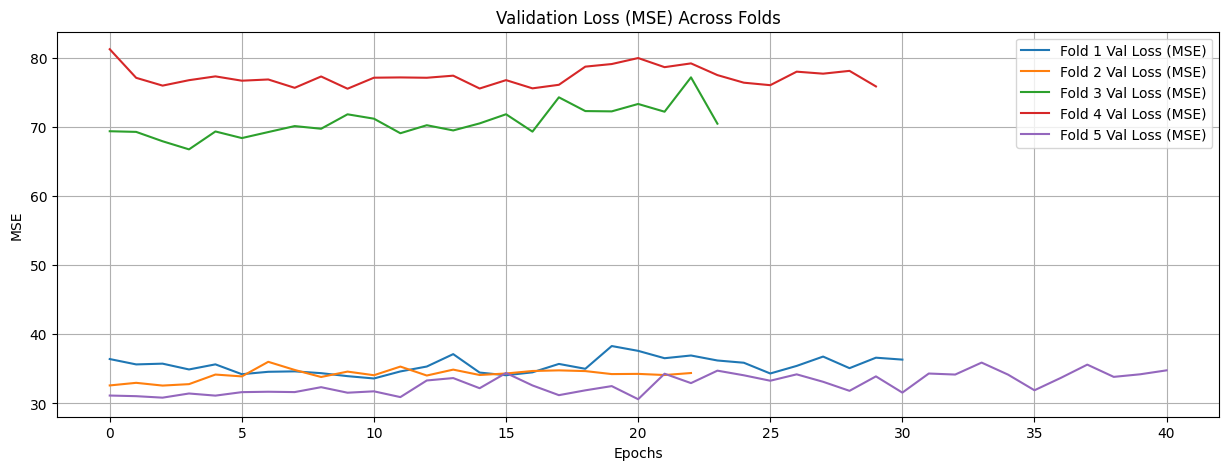

Overall R-squared on concatenated CV validation data: 0.0403
--- Performance by Age Category (on all CV validation samples) ---
  Category: Younger (Samples: 1571)
    MSE: 53.4395, MAE: 5.1570, R-squared: 0.0644
  Category: Older (Samples: 727)
    MSE: 38.1305, MAE: 4.7596, R-squared: -0.0507


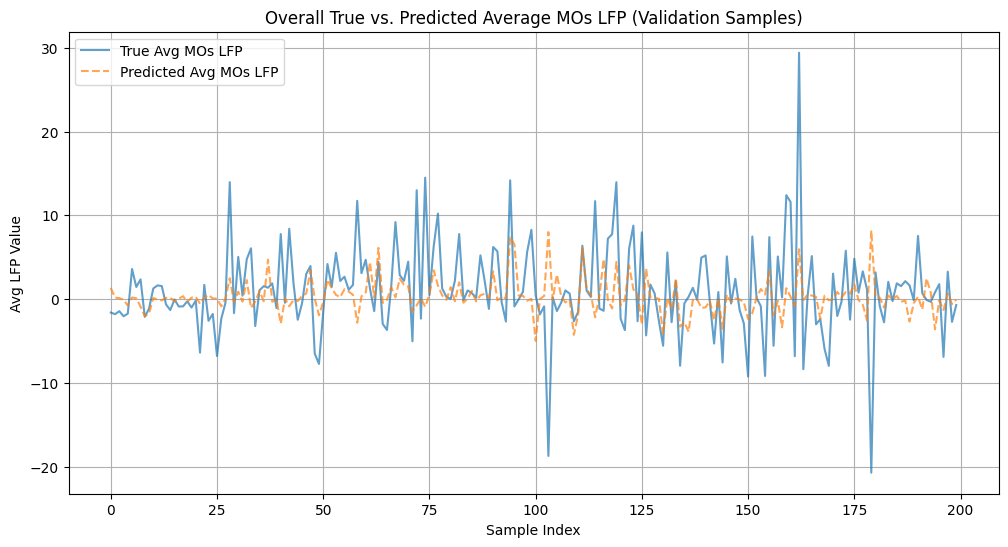

Script analysis section completed.


In [16]:
# Cell 8: Results Aggregation and Age-Based Evaluation
if 'X_final' not in globals() or not isinstance(X_final, np.ndarray) or X_final.size == 0 or 'Y_final' not in globals() or not isinstance(Y_final, np.ndarray) or Y_final.size == 0 or  not fold_val_mse: 
    print("Skipping results aggregation.")
else:
    print("--- Cross-Validation Summary ---")
    print(f"Average Validation MSE across {N_SPLITS_CV} folds: {np.nanmean(fold_val_mse):.4f} (+/- {np.nanstd(fold_val_mse):.4f})")
    print(f"Average Validation MAE across {N_SPLITS_CV} folds: {np.nanmean(fold_val_mae):.4f} (+/- {np.nanstd(fold_val_mae):.4f})")
    print(f"Average Validation R-squared across {N_SPLITS_CV} folds: {np.nanmean(fold_val_r2):.4f} (+/- {np.nanstd(fold_val_r2):.4f})")
    
    if fold_histories:
        plt.figure(figsize=(15, 5))
        for i, history_fold in enumerate(fold_histories):
            if history_fold and hasattr(history_fold, 'history') and 'val_loss' in history_fold.history:
                 plt.plot(history_fold.history['val_loss'], label=f'Fold {i+1} Val Loss (MSE)')
            else:
                 print(f"Warning: History for fold {i+1} is missing or malformed.")
        plt.title('Validation Loss (MSE) Across Folds')
        plt.xlabel('Epochs'); plt.ylabel('MSE'); plt.legend(); plt.grid(True); plt.show()
    else:
        print("No training histories recorded to plot.")

    if all_y_true_val_folds and all_y_pred_val_folds and all_age_categories_val_folds:
        Y_true_all_cv = np.concatenate(all_y_true_val_folds, axis=0)
        Y_pred_all_cv = np.concatenate(all_y_pred_val_folds, axis=0)
        age_cat_all_cv = np.concatenate(all_age_categories_val_folds, axis=0)
        
        if Y_true_all_cv.shape[0] > 1 and len(np.unique(Y_true_all_cv.flatten())) > 1 :
            overall_r2 = r2_score(Y_true_all_cv, Y_pred_all_cv)
            print(f'Overall R-squared on concatenated CV validation data: {overall_r2:.4f}')
        else:
            print(f'Overall R-squared: Not enough samples or variance in Y_true_all_cv.')
        print("--- Performance by Age Category (on all CV validation samples) ---")
        for category in ['Younger', 'Older']:
            cat_indices = (age_cat_all_cv == category)
            if np.any(cat_indices):
                y_true_cat = Y_true_all_cv[cat_indices]
                y_pred_cat = Y_pred_all_cv[cat_indices]
                if len(y_true_cat) > 1 and len(np.unique(y_true_cat.flatten())) > 1:
                    mse_cat = mean_squared_error(y_true_cat, y_pred_cat)
                    mae_cat = mean_absolute_error(y_true_cat, y_pred_cat)
                    r2_cat = r2_score(y_true_cat, y_pred_cat)
                    print(f'  Category: {category} (Samples: {len(y_true_cat)})')
                    print(f'    MSE: {mse_cat:.4f}, MAE: {mae_cat:.4f}, R-squared: {r2_cat:.4f}')
                else:
                    print(f'  Category: {category} (Samples: {len(y_true_cat)}) - Not enough samples/variance for R2.')
                    if len(y_true_cat) > 0:
                        print(f'MSE: {mean_squared_error(y_true_cat, y_pred_cat):.4f}, MAE: {mean_absolute_error(y_true_cat, y_pred_cat):.4f}')
                        
            else:
                print(f'  Category: {category} - No samples in validation set.')
                
        if Y_true_all_cv.shape[0] > 0:
            plt.figure(figsize=(12, 6))
            plot_samples = min(200, Y_true_all_cv.shape[0])
            plt.plot(Y_true_all_cv[:plot_samples, 0], label='True Avg MOs LFP', alpha=0.7)
            plt.plot(Y_pred_all_cv[:plot_samples, 0], label='Predicted Avg MOs LFP', linestyle='--', alpha=0.7)
            plt.title('Overall True vs. Predicted Average MOs LFP (Validation Samples)')
            plt.xlabel('Sample Index'); plt.ylabel('Avg LFP Value'); plt.legend(); plt.grid(True); plt.show()
        else:
            print("No validation samples to plot.")
    else:
        print("No validation predictions recorded.")
        
print("Script analysis section completed.")


Interpretation of Results:

Average Validation MSE (Mean Squared Error): 47.8083 (+/- 19.2559)
MSE measures the average squared difference between the actual and predicted values. A lower MSE is better.
The value of 47.8 is relatively high (assuming your LFP values are not on a very large scale). The large standard deviation (+/- 19.25) indicates considerable variability in performance across the 5 cross-validation folds. Some folds performed much better or worse than the average.

Average Validation MAE (Mean Absolute Error): 4.9759 (+/- 1.1194)
MAE measures the average absolute difference between actual and predicted values. It's more interpretable in the original units of your target variable (average LFP value).
An MAE of ~5 means that, on average, your model's predictions are off by about 5 units of LFP amplitude. The standard deviation (+/- 1.12) also shows some variability across folds.
Average Validation R-squared: 0.0023 (+/- 0.0530)

R-squared (Coefficient of Determination) indicates the proportion of the variance in the dependent variable (target MOs LFP) that is predictable from the independent variable (input VISp LFP).
Values range from -∞ to 1.
1 indicates a perfect fit.
0 indicates the model performs no better than simply predicting the mean of the target variable.
Negative values indicate the model performs worse than predicting the mean.
Your average R-squared of 0.0023 is extremely close to zero. This implies that your model, on average across the folds, explains almost none of the variance in the target MOs LFP signal. It's essentially not capturing any meaningful relationship between the VISp LFP input and the averaged MOs LFP output.
The standard deviation (+/- 0.0530) means some folds likely had slightly positive R-squared values (still very low) and others likely had negative R-squared values.
Overall Implication:
The current model (LSTM without PCA, with upsampling if it was active) is not effective at predicting the time-averaged MOs LFP signal from the provided VISp LFP features. The features used (VISp LFP time series, potentially averaged down to 1 channel per your previous output, even if Cell 5 was intended to keep multiple) and the target definition (heavily averaged MOs LFP) do not seem to have a strong, learnable linear or non-linear relationship that this LSTM architecture can capture.
The model is performing, on average, only negligibly better (or in some folds, worse) than if you were to just guess the average MOs LFP value for every trial.